In [2]:
import numpy as np
import matplotlib.pyplot as plt

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (COPPER_AVERAGE_REGIONS_TO_IMAGE, 
                                          REGION_TO_CLASS_DICT,
                                          models_output_dict)

In [3]:
# COPPER
copper = ResourceModel(resource_group = 'metals', resource = 'copper', 
                       image_mat_available = True, start_year = 2012,
                       scenario= 'SSP2_M_CP')

all_regions = list(COPPER_AVERAGE_REGIONS_TO_IMAGE.keys())
oceania_eu_usa = ['Europe', 'USA', 'Oceania']
asia = ['China', 'Japan', 'Korea']
rest = [region for region in all_regions if region not in oceania_eu_usa + asia]

copper_regions = {
    'all_regions': all_regions,
    'oceania_eu_usa' : oceania_eu_usa,
    'asia':asia}

copper.data_grouped_regions(regions_grouping = copper_regions) #list(COPPER_AVERAGE_REGIONS_TO_IMAGE.keys()
copper.sum_IMAGE_drivers_regions(COPPER_AVERAGE_REGIONS_TO_IMAGE)
copper.match_MAT_data_to_regions_year(match_external_regions=True)
copper.calculate_historic_other_fraction()

In [4]:
# deal with single negative numbers in historic other fraction by replacing with np.nan
copper.historic_other_fraction_consumption[copper.historic_other_fraction_consumption < 0] = np.nan
copper.historic_other_fraction_consumption


,Africa,China,Europe,India,Japan,Korea,Oceania,Other North America countries,Rest of Asia,South America,USA
2012,NaN,6.802981e+06,2.261163e+06,328120.983785,801373.547460,668455.510669,37175.555109,19141.547029,1.042737e+06,463674.442698,806973.604454
2013,NaN,7.576939e+06,2.086888e+06,337519.442954,785555.328818,661436.402751,19155.493038,215615.934010,8.224952e+05,525737.162475,780882.114683
2014,NaN,8.473371e+06,2.107213e+06,359654.862944,768317.522090,595977.656717,22706.949387,NaN,7.085295e+05,309475.069121,689669.203527
2015,NaN,8.322112e+06,1.672890e+06,347208.614979,645969.776674,561227.774215,NaN,44802.218191,6.374004e+05,189908.704953,492594.871262
2016,NaN,8.687888e+06,1.639632e+06,391147.132119,759685.683007,618228.911645,21482.982929,275700.430092,8.756671e+05,527818.051238,772932.159720
2017,NaN,8.888019e+06,1.605835e+06,435313.657526,736306.521309,627348.602250,11919.901086,250230.328025,7.740472e+05,477061.056117,794647.399072


In [5]:
# deal with negative numbers for Africa by assuming IMAGE Mat values are right + 
# adding a fraction on top that is similar to the other countries

# share_mat_data = copper.image_mat_material_regions/copper.historic_consumption_data
# mean = share_mat_data.loc[:, "China" : "USA"].mean().mean() # MAT data is roughly 50% of total consumption in other regions --> assume same for African regions
# #TODO or better on per capita level than on total region level?

# africa_copper_mat = copper.image_mat_material_regions["Africa"]

# tota_africa_new = africa_copper_mat/(mean*100)*100

# # 1- mean is part of total copper consumption that is not covered by MAT
# share_to_project_africa = tota_africa_new*(1-mean)

# # replace nan values for Africa
# copper.historic_other_fraction_consumption["Africa"] = share_to_project_africa


In [6]:
# Fit models 

best_rmse_models= {
    'all_regions' : 'gompertz model',
    'oceania_eu_usa' : 'gompertz model',
    'asia' : 'gompertz model'}


bounds = {
    'all_regions' : ([0, 0, 0], [10, 10, 10]),
    'oceania_eu_usa' : ([0, 2, 2], [10, 10, 10]),
    'asia' : ([0, 1, 1], [10, 10, 10])}


copper.calculate_regressors(copper.historic_other_fraction_consumption)
copper.fit_models(best_rmse_models=best_rmse_models, bounds=bounds)

C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d


In [7]:
# Projections 
copper.project_on_total(list(COPPER_AVERAGE_REGIONS_TO_IMAGE.keys()))

# add regions to regions model match that are not in there yet becaused they are fitted to the global average
for key in COPPER_AVERAGE_REGIONS_TO_IMAGE.keys():
    if key not in copper.region_model_match:
        copper.region_model_match[key] = copper.model_groups.get("all_regions")[6]

Other North America countries could not be projected, choose global fit
South America could not be projected, choose global fit
Rest of Asia could not be projected, choose global fit
Africa could not be projected, choose global fit
India could not be projected, choose global fit


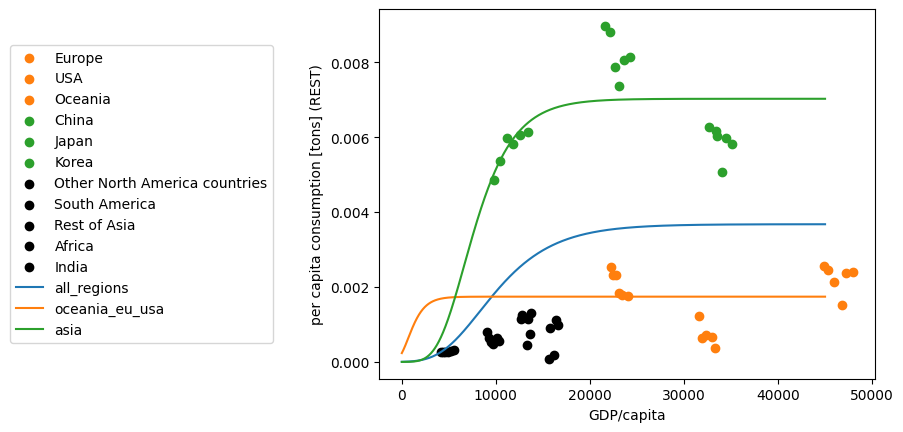

In [8]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis

color_dict = {
    'all_regions' : '#1f77b4',  # blue
    'oceania_eu_usa' : '#ff7f0e',  # orange
    'asia' : '#2ca02c',  # green
    'rest' : "#000000"  # black
}


fig, ax = plt.subplots()             # Create a figure containing a single Axes.

for key, regions in copper_regions.items():
    if key == 'all_regions':
        continue
    for region in regions:
        ax.scatter(copper.gdp_pc[region], 
                copper.cons_capita[region], 
                label = region,
                color = color_dict[key])
    
for region in rest:
    ax.scatter(copper.gdp_pc[region], 
               copper.cons_capita[region], 
               label = region,
               color = color_dict['rest'])

for grouping in copper_regions.keys():
    model = copper.model_groups[grouping][models_output_dict[copper.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 45000).reshape(-1, 1)),
            label = grouping)
    
ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")
ax.legend(loc = 'right', bbox_to_anchor=(-0.2, 0.5))
    

In [9]:
copper.smooth_out_interpolation_all(10, 2017)

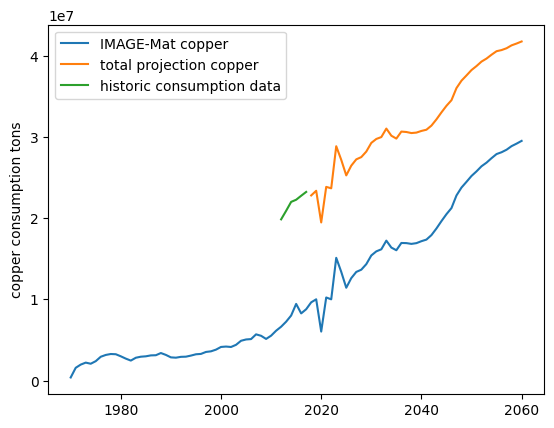

In [10]:
# Plot total copper consumption (all regions)
fig, ax = plt.subplots()             # Create a figure containing a single Axes.


ax.plot(copper.image_mat_data.sum(axis = 1).loc[1970:], label = "IMAGE-Mat copper")
ax.plot((copper.projection_per_region*copper.pop_100.loc[2018:]).sum(axis = 1) + copper.image_mat_data.sum(axis = 1).loc[2018:],
        label = "total projection copper")
ax.plot(copper.historic_consumption_data.sum(axis = 1), label = "historic consumption data")

ax.set_ylabel("copper consumption tons")

ax.legend(loc = 'upper left')

plt.show()

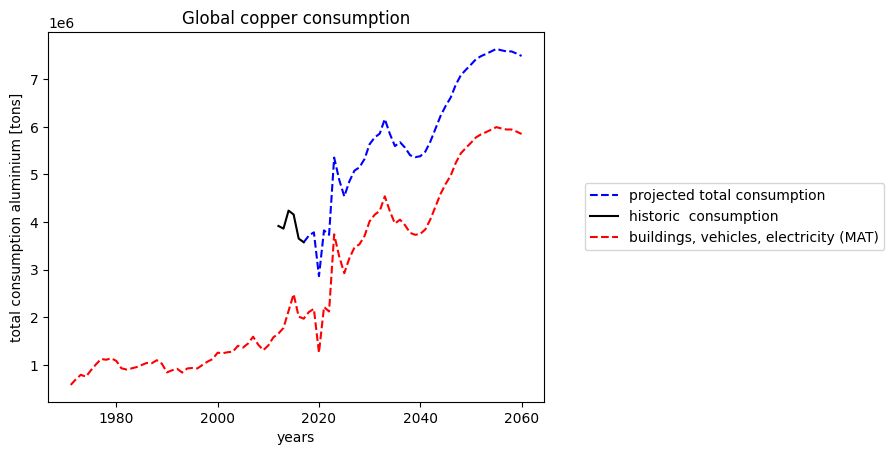

In [11]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

region = 'Europe'

ax.plot(copper.projection_per_region_total[region].loc[:] + copper.image_mat_material_regions_total[region].loc[2017:, ],
linestyle = '--', color = 'blue', label = 'projected total consumption')

ax.plot(copper.historic_consumption_data[region],
        linestyle = '-', color = 'black', label = 'historic  consumption')  

ax.plot(copper.image_mat_material_regions_total[region].loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')

ax.set_ylabel("total consumption aluminium [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global copper consumption")
ax.legend(loc = 'right', bbox_to_anchor=(1.7, 0.5))